# Data Science Mini Project

**Student Name:VARSHA A**

**Batch: DS AN B03**

**Project Title:Intelligent Resume - Job Matching & Skill Analysis System**

**Submission Date:**

# 1. Problem Definition

## 1.1 Business / Real-World Problem Statement

Recruiters and job seekers often need to determine how well a resume matches the requirements of a particular job role. Manually comparing candidate skills, experience, education, seniority, industry, and other job requirements can be time-consuming, especially when dealing with a large number of resumes and job openings.

This project aims to develop a machine learning dataset for predicting whether a particular resume is relevant to a given job. The project combines resume information with job information and creates meaningful matching features such as skill overlap, skill match ratio, seniority match, and industry match.

These features are then transformed into a structured machine learning dataset that can be used to train a supervised classification model. The trained model can predict whether a given resume–job pair is relevant or non-relevant.

## 1.2 Project Objectives

The main objectives of this project are to:

1. Analyze the resume and job datasets to understand their structure, attributes, and data quality.
2. Perform exploratory data analysis on relevant resume and job attributes.
3. Clean and preprocess the available resume and job data.
4. Combine resume and job information to create a resume–job matching dataset.
5. Generate meaningful features that represent the compatibility between a resume and a job.
6. Create features such as skill overlap, skill match ratio, seniority match, and industry match.
7. Convert categorical features into suitable numerical representations.
8. Scale numerical features where required.
9. Separate the resulting dataset into training and testing datasets.
10. Analyze relationships between numerical features using correlation analysis.
11. Apply SelectKBest for selecting the most relevant features for model development.
12. Prepare the final training and testing datasets for machine learning classification models.
13. Save the processed training and testing datasets so that they can be reused for further model development and evaluation.

## 1.3 Machine Learning Problem Type

**Selected Problem Type:**

☑ **Supervised Learning – Classification**

The target variable represents whether a particular **resume–job pair is relevant or non-relevant**.

Therefore, the machine learning task is a **binary classification problem**, where the model learns patterns from previously labelled resume–job pairs and predicts the relevance of new resume–job pairs.


# 2. Dataset Understanding

## 2.1 Dataset Source

**Dataset Source:** Hugging Face Datasets

**Dataset Name:** `candidate-matching-synthetic`

**Dataset Author:** `michaelozon`

**Source Link:** [Hugging Face – Candidate Matching Synthetic Dataset](https://huggingface.co/datasets/michaelozon/candidate-matching-synthetic?)

The dataset is a synthetic candidate-matching dataset designed for recruitment and job-matching applications. The dataset page identifies its use cases as recruitment, job matching, resume screening, semantic search, and embeddings. It is available in English and is provided under the MIT license.

The project uses the following CSV files derived from the dataset:

* `Resume.csv`
* `Jobs.csv`
* `matches.csv`

These datasets are used to construct resume–job pairs and develop features for predicting whether a candidate resume is relevant to a particular job.

## 2.2 Dataset Description

The project consists of three related datasets that are used together to construct the final resume–job matching dataset.

### Resume Dataset

The `Resume.csv` dataset contains **13,200 rows and 9 columns**.

Each row represents a candidate resume. It contains information such as the candidate's role, seniority level, years of experience, industry, education, skills, summary, and experience details. This dataset provides the information needed to understand the candidate's background and qualifications.

### Jobs Dataset

The `Jobs.csv` dataset contains **3,400 rows and 9 columns**.

Each row represents a job opportunity. It contains information such as the job title, required seniority, industry, required skills, preferred skills, job description, responsibilities, and requirements. This dataset provides the information needed to understand what each job expects from a candidate.

### Matches Dataset

The `matches.csv` dataset contains **3,400 rows and 2 columns**.

It connects `job_id` with the relevant `resume_id` values. In other words, it identifies which resumes are considered relevant to each job. These relationships are used as the source of **positive resume–job pairs** during the matching-data construction process.

### Resume–Job Pair Dataset

The three datasets are combined to create individual resume–job pairs. Each pair represents a combination of one candidate and one job.

Positive pairs are created using the relevant resume–job relationships provided in `matches.csv`. Additional negative pairs are created by pairing jobs with resumes that are not considered relevant to those jobs. This allows the final dataset to contain both matching and non-matching examples.

After generating the positive and negative pairs, the matching dataset contains **204,000 observations and 3 columns** before the resume and job attributes are merged.

The corresponding resume and job information is then merged into these pairs. This produces a combined dataset containing **204,000 rows and 23 columns**, which is used for further exploratory analysis, feature engineering, and preprocessing.


## 2.3 Feature Description

### Resume Dataset Features

| Feature Name         | Data Type   | Description                                   |
| -------------------- | ----------- | --------------------------------------------- |
| `resume_id`          | Object      | Unique identifier for each resume             |
| `role`               | Categorical | Role associated with the candidate            |
| `seniority`          | Categorical | Seniority level of the candidate              |
| `years_experience`   | Numeric     | Number of years of professional experience    |
| `industry`           | Categorical | Industry associated with the candidate        |
| `education`          | Categorical | Educational background of the candidate       |
| `skills`             | Text        | Skills listed in the resume                   |
| `summary`            | Text        | Candidate's professional summary              |
| `experience_bullets` | Text        | Details describing the candidate's experience |

### Jobs Dataset Features

| Feature Name          | Data Type   | Description                              |
| --------------------- | ----------- | ---------------------------------------- |
| `job_id`              | Object      | Unique identifier for each job           |
| `job_title`           | Categorical | Title of the job                         |
| `seniority`           | Categorical | Required seniority level for the job     |
| `industry`            | Categorical | Industry associated with the job         |
| `must_have_skills`    | Text        | Skills required for the job              |
| `nice_to_have_skills` | Text        | Additional desirable skills              |
| `description`         | Text        | Description of the job                   |
| `responsibilities`    | Text        | Responsibilities associated with the job |
| `requirements`        | Text        | Requirements specified for the job       |

### Matches Dataset Features

| Feature Name          | Data Type | Description                                             |
| --------------------- | --------- | ------------------------------------------------------- |
| `job_id`              | Object    | Identifier of the job                                   |
| `relevant_resume_ids` | Object    | Resume IDs considered relevant to the corresponding job |


## 2.4 Target Variable

**Target Variable:** `target`

The target variable represents the relevance of a particular resume–job pair.

| Target Value | Meaning                      |
| ------------ | ---------------------------- |
| `1`          | Relevant resume–job pair     |
| `0`          | Non-relevant resume–job pair |

# 3. Exploratory Data Analysis (EDA)
## 3.1 Import Required Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

## 3.2 Load Dataset

In [4]:
Resume = pd.read_csv("Resume.csv")
Jobs = pd.read_csv("Jobs.csv")
matches = pd.read_csv("matches.csv")

print("Resume:", Resume.shape)
print("Jobs:", Jobs.shape)
print("Matches:", matches.shape)

Resume: (13200, 9)
Jobs: (3400, 9)
Matches: (3400, 2)


## 3.3 Dataset Overview

In [5]:
Resume.head()

,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Tes...",Software Engineer with 12 years of experience ...,[Delivered results using structured workflows ...
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optim...",Marketing Manager with 2 years of experience i...,[Delivered results using structured workflows ...
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience...,[Delivered results using structured workflows ...
3,R_000003,Data Analyst,Junior,0,Healthcare,BSc,"[Excel, A/B Testing, Tableau, Pandas, Power BI...",Data Analyst with 0 years of experience in Hea...,[Delivered results using structured workflows ...
4,R_000004,BI Analyst,Junior,0,Gaming,BA,"[Statistics, SQL, Power BI, Pandas, Excel]",BI Analyst with 0 years of experience in Gaming.,[Delivered results using structured workflows ...


In [6]:
matches.head()

,job_id,relevant_resume_ids
0,J_000000,"[R_000915, R_003468, R_003641, R_003326, R_008..."
1,J_000001,"[R_003953, R_009866, R_009933, R_009826, R_007..."
2,J_000002,"[R_001833, R_005742, R_001158, R_000978, R_007..."
3,J_000003,"[R_002054, R_008377, R_003385, R_001576, R_006..."
4,J_000004,"[R_002908, R_003365, R_008335, R_005987, R_006..."


In [7]:
Jobs.head()

,job_id,job_title,seniority,industry,must_have_skills,nice_to_have_skills,description,responsibilities,requirements
0,J_000000,Project Manager,Senior,Retail,"[Timeline Management, Process Improvement, Sta...",[Asana],We are hiring a Project Manager to support tea...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
1,J_000001,Customer Success Associate,Senior,EdTech,"[Troubleshooting, Customer Satisfaction, Inter...",[Root Cause Analysis],We are hiring a Customer Success Associate to ...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
2,J_000002,FP&A Analyst,Junior,Travel,"[Variance Analysis, Excel, KPIs]",[Valuation],We are hiring a FP&A Analyst to support teams ...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
3,J_000003,Full Stack Engineer,Junior,Cybersecurity,"[Git, OOP, CI/CD, Java]",[Docker],We are hiring a Full Stack Engineer to support...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
4,J_000004,Associate Product Manager,Senior,SaaS,"[A/B Testing, PRD, Product Strategy, Agile, Pr...",[User Research],We are hiring a Associate Product Manager to s...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...


In [8]:
print("Resume Dataset")
Resume.info()

Resume Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   resume_id           13200 non-null  object
 1   role                13200 non-null  object
 2   seniority           13200 non-null  object
 3   years_experience    13200 non-null  int64 
 4   industry            13200 non-null  object
 5   education           13200 non-null  object
 6   skills              13200 non-null  object
 7   summary             13200 non-null  object
 8   experience_bullets  13200 non-null  object
dtypes: int64(1), object(8)
memory usage: 928.3+ KB


In [9]:
print("\nJobs Dataset")
Jobs.info()


Jobs Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               3400 non-null   object
 1   job_title            3400 non-null   object
 2   seniority            3400 non-null   object
 3   industry             3400 non-null   object
 4   must_have_skills     3400 non-null   object
 5   nice_to_have_skills  3400 non-null   object
 6   description          3400 non-null   object
 7   responsibilities     3400 non-null   object
 8   requirements         3400 non-null   object
dtypes: object(9)
memory usage: 239.2+ KB


In [10]:
print("\nMatches Dataset")
matches.info()


Matches Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               3400 non-null   object
 1   relevant_resume_ids  3400 non-null   object
dtypes: object(2)
memory usage: 53.3+ KB


In [11]:
print("Resume Columns:")
print(Resume.columns.tolist())

print("\nJobs Columns:")
print(Jobs.columns.tolist())

print("\nMatches Columns:")
print(matches.columns.tolist())


Resume Columns:
['resume_id', 'role', 'seniority', 'years_experience', 'industry', 'education', 'skills', 'summary', 'experience_bullets']

Jobs Columns:
['job_id', 'job_title', 'seniority', 'industry', 'must_have_skills', 'nice_to_have_skills', 'description', 'responsibilities', 'requirements']

Matches Columns:
['job_id', 'relevant_resume_ids']


In [12]:
print("Resume Summary Statistics")
display(Resume.describe(include="all").T)

Resume Summary Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
resume_id,13200,13200,R_000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
role,13200,31,Data Analyst,904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seniority,13200,3,Junior,4682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_experience,13200.0,NaN,NaN,NaN,4.698939,3.68162,0.0,2.0,4.0,7.0,15.0
industry,13200,10,Retail,1404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,13200,8,BSc,2586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
skills,13200,10596,"[SQL, Python, Excel, Power BI, Tableau, Statis...",74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
summary,13200,3767,Data Analyst with 2 years of experience in E-c...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_bullets,13200,3,[Delivered results using structured workflows ...,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print("\nJobs Summary Statistics")
display(Jobs.describe(include="all").T)


Jobs Summary Statistics


,count,unique,top,freq
job_id,3400,3400,J_000000,1
job_title,3400,32,Data Analyst,189
seniority,3400,3,Junior,1238
industry,3400,10,Healthcare,380
must_have_skills,3400,2453,"[Network Security, SIEM, SOC, Linux, Incident ...",100
nice_to_have_skills,3400,85,"[Splunk, CrowdStrike, Nmap, Burp Suite, AWS Se...",100
description,3400,300,We are hiring a Data Analyst to support teams ...,24
responsibilities,3400,3,[Deliver high-quality work aligned with goals ...,2500
requirements,3400,6,[Relevant experience and ability to learn quic...,2500


# 3.4 Missing Value Analysis

In [14]:
print("Missing Values in Resume:")
print(Resume.isnull().sum())

print("\nMissing Values in Jobs:")
print(Jobs.isnull().sum())

print("\nMissing Values in Matches:")
print(matches.isnull().sum())


Missing Values in Resume:
resume_id             0
role                  0
seniority             0
years_experience      0
industry              0
education             0
skills                0
summary               0
experience_bullets    0
dtype: int64

Missing Values in Jobs:
job_id                 0
job_title              0
seniority              0
industry               0
must_have_skills       0
nice_to_have_skills    0
description            0
responsibilities       0
requirements           0
dtype: int64

Missing Values in Matches:
job_id                 0
relevant_resume_ids    0
dtype: int64


## 3.5 Correlation Analysis

### Initial Correlation Analysis

- Correlation analysis was performed on the numerical variables in the merged dataset.
- The initial numerical features included:
  - `years_experience`
  - `required_skill_count`
- The initial analysis showed that `skill_count` had a small positive correlation with the target.
- `years_experience` showed a very small correlation with the target.

In [15]:
numerical_cols = Resume.select_dtypes(include=np.number).columns
correlation_matrix = Resume[numerical_cols].corr()

correlation_matrix

,years_experience
years_experience,1.0


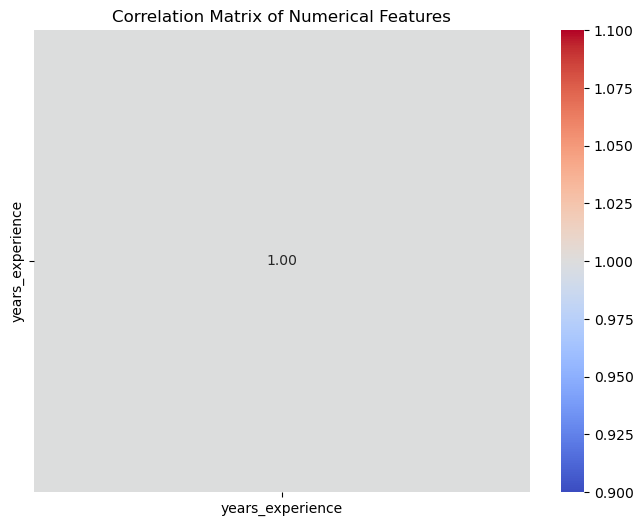

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

## 3.6 Visualizations

### Visualization 1: Distribution of Years of Experience

- A histogram with a KDE curve was used to examine the distribution of `years_experience` in the Resume dataset.
- This visualization helps identify the distribution and possible skewness of candidate experience levels.

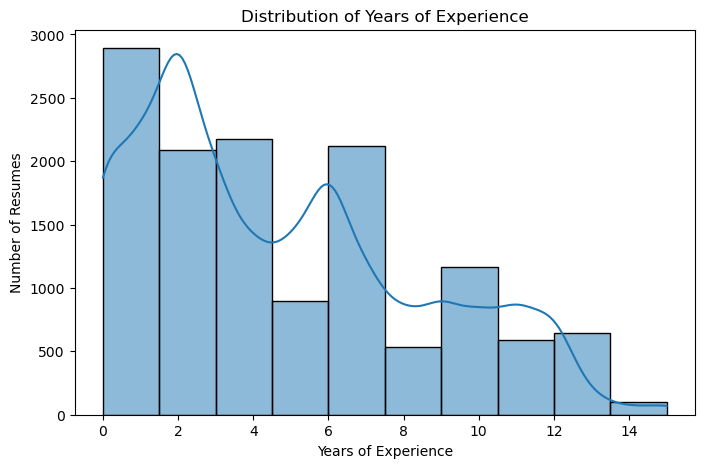

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(Resume["years_experience"], bins=10, kde=True)
plt.title("Distribution of Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Resumes")

plt.show()

### Visualization 2: Resume Seniority Distribution

- A count plot was used to examine the distribution of candidate seniority levels.
- The dataset contains **three seniority categories**, with **Junior** being the most frequent category.

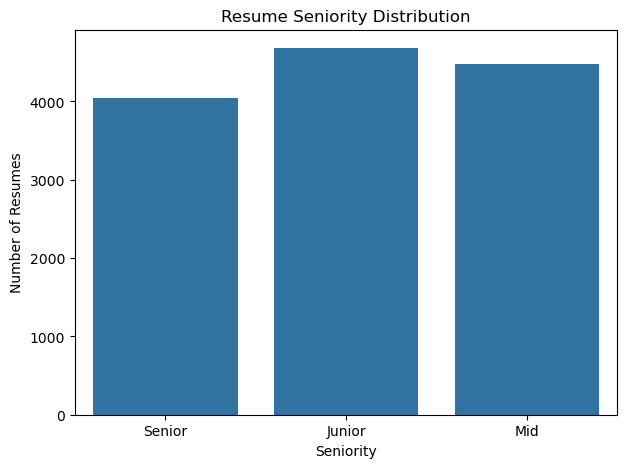

In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(data=Resume, x="seniority")
plt.title("Resume Seniority Distribution")
plt.xlabel("Seniority")
plt.ylabel("Number of Resumes")

plt.show()

### Visualization 3: Top 10 Resume Roles

- The ten most frequent resume roles were visualized using a bar chart.
- The analysis showed that **Data Analyst** is the most frequent role in the Resume dataset.

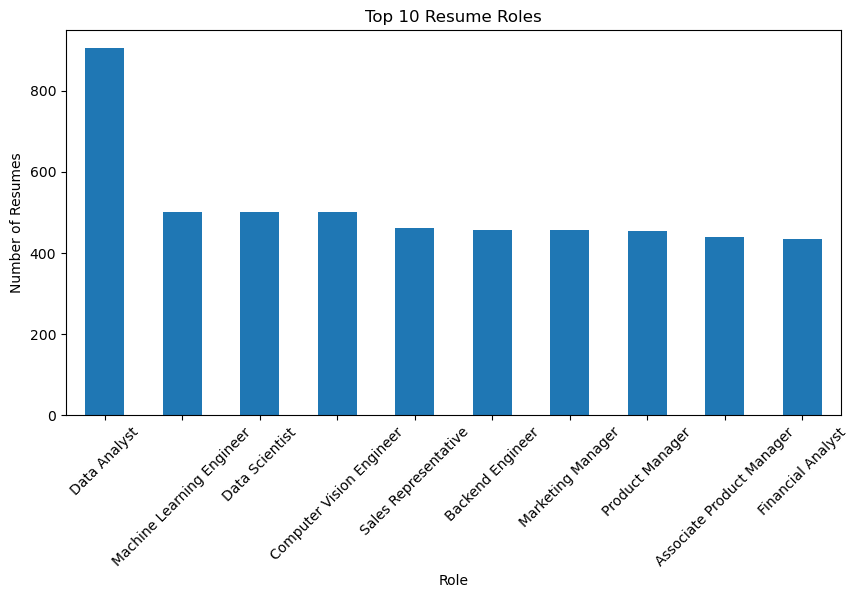

In [19]:
plt.figure(figsize=(10, 5))
Resume["role"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Resume Roles")
plt.xlabel("Role")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45)

plt.show()

### Visualization 4: Resume Distribution by Industry

- A bar chart was used to examine the distribution of resumes across industries.
- The Resume dataset contains **10 industries**, with **Retail** being the most represented industry.

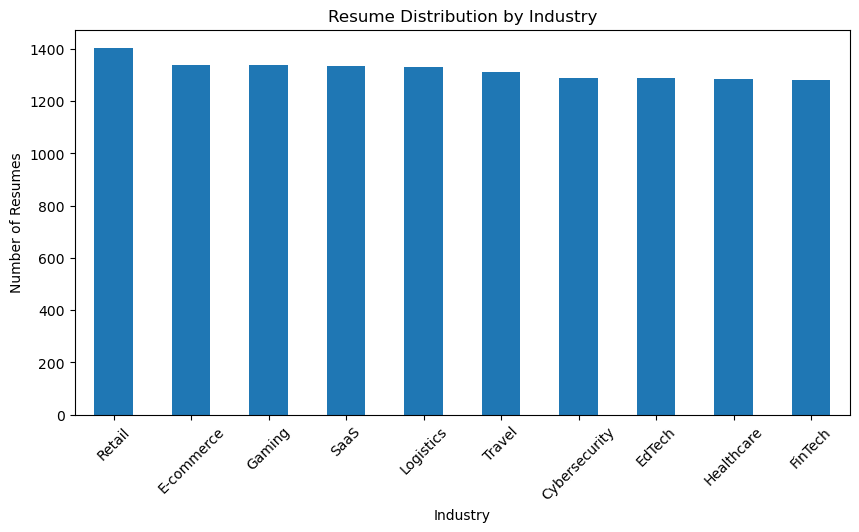

In [20]:
plt.figure(figsize=(10, 5))
Resume["industry"].value_counts().plot(kind="bar")
plt.title("Resume Distribution by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45)

plt.show()

### Visualization 5: Education Distribution

- A bar chart was used to visualize the distribution of educational backgrounds.
- The dataset contains **8 education categories**, with **BSc** being the most frequent category.

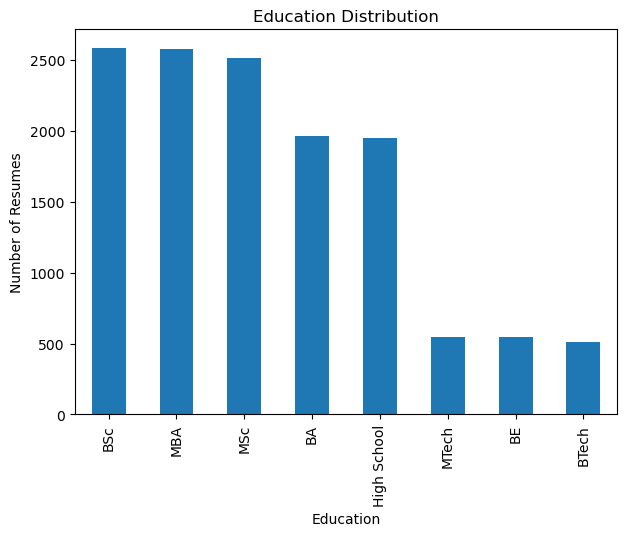

In [21]:
plt.figure(figsize=(7, 5))
Resume["education"].value_counts().plot(kind="bar")
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Number of Resumes")

plt.show()

### Visualization 6: Job Seniority Distribution

- A count plot was used to examine the seniority requirements of the available jobs.
- The Jobs dataset contains **three seniority categories**, with **Junior** being the most frequent category.

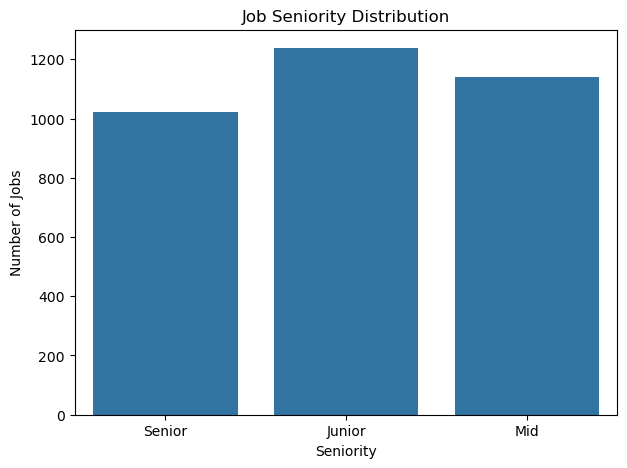

In [22]:
plt.figure(figsize=(7, 5))
sns.countplot(data=Jobs, x="seniority")
plt.title("Job Seniority Distribution")
plt.xlabel("Seniority")
plt.ylabel("Number of Jobs")

plt.show()

### Visualization 7: Jobs by Industry

- A bar chart was used to visualize the number of jobs across different industries.
- The Jobs dataset contains **10 industries**, with **Healthcare** being the most represented industry.

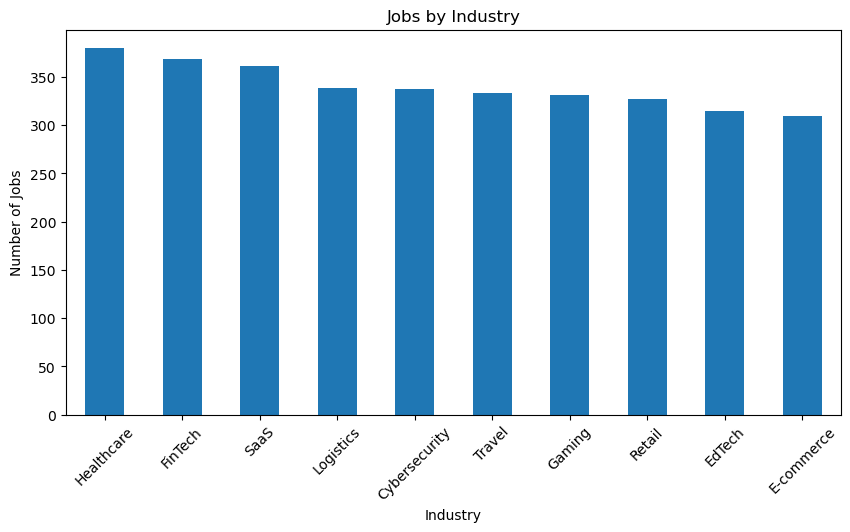

In [23]:
plt.figure(figsize=(10, 5))
Jobs["industry"].value_counts().plot(kind="bar")
plt.title("Jobs by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

### Visualization 8: Top 10 Job Titles

- A bar chart was used to display the ten most frequent job titles.
- The most frequent job title in the Jobs dataset is **Data Analyst**.

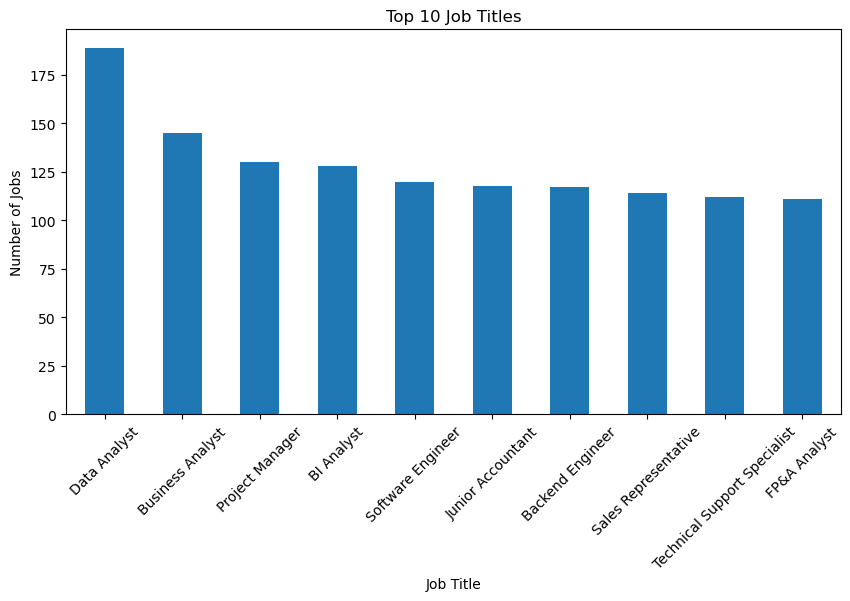

In [24]:
plt.figure(figsize=(10, 5))
Jobs["job_title"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

### Visualization 9: Boxplot of Years of Experience

- A boxplot was used to examine the distribution of `years_experience` in the Resume dataset.
- The boxplot helps identify the **median, spread, and potential outliers** in candidate experience levels.
- This visualization was used as part of the **outlier analysis** before applying the IQR-based treatment.

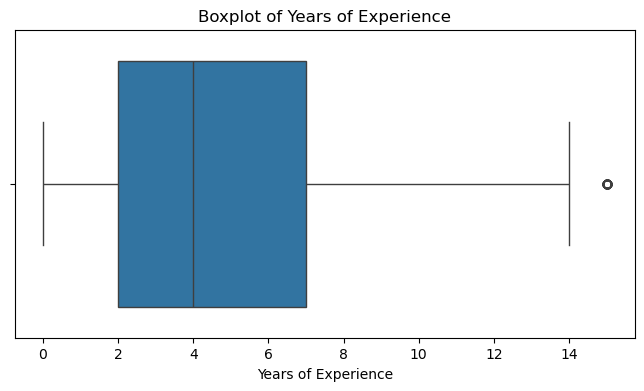

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=Resume["years_experience"])
plt.title("Boxplot of Years of Experience")
plt.xlabel("Years of Experience")

plt.show()

## Observations

- The Resume dataset contains **13,200 records and 9 columns**, while the Jobs dataset contains **3,400 records and 9 columns** and the Matches dataset contains **3,400 records and 2 columns**.
- The datasets contain complete records with no major missing-value issue observed during the initial analysis.
- The Resume dataset contains **31 roles, 3 seniority levels, 10 industries, and 8 education categories**.
- `years_experience` is the main numerical feature in the original Resume dataset, with values ranging from **0 to 15 years** and an average of approximately **4.7 years**.
- The EDA showed that **Junior** is the most common seniority level in both resumes and job requirements.
- **Data Analyst** is the most frequent resume role and also the most frequent job title in the available datasets.
- **Retail** is the most represented industry in the Resume dataset, while **Healthcare** is the most represented industry in the Jobs dataset.
- **BSc** is the most frequent educational qualification among the resumes.
- The boxplot of `years_experience` indicated the presence of potential extreme values, which were examined further during the preprocessing stage.
- Initial correlation analysis showed that the numerical features had relatively small linear relationships with the target, indicating that additional matching and categorical features would be useful for the classification task.

# 4. Data Preprocessing

## 4.1 Missing Value Treatment

* The original `Resume.csv`, `Jobs.csv`, and `matches.csv` datasets were checked for missing values to identify whether any columns required treatment before further analysis and preprocessing.

* The inspection showed that the original datasets did not contain missing values that required explicit imputation.

* Therefore, mean, median, or mode imputation was not required at the raw-data stage.

* During later feature construction and preprocessing, `fillna(0)` is used where required to ensure that numerical features do not contain missing values.

### Observation

Since the original datasets do not contain missing values requiring imputation, applying mean, median, or mode imputation at the raw-data stage is unnecessary. The datasets can therefore proceed to the subsequent preprocessing steps without replacing any original values.

### Overview

The three original datasets were checked for missing values before preprocessing. No raw-data imputation was required. Where missing values may occur as a result of later feature construction, appropriate numerical handling such as `fillna(0)` is applied before the final dataset is prepared.


In [26]:
print("Resume missing values:")
print(Resume.isnull().sum())

print("\nJobs missing values:")
print(Jobs.isnull().sum())

print("\nMatches missing values:")
print(matches.isnull().sum())

Resume missing values:
resume_id             0
role                  0
seniority             0
years_experience      0
industry              0
education             0
skills                0
summary               0
experience_bullets    0
dtype: int64

Jobs missing values:
job_id                 0
job_title              0
seniority              0
industry               0
must_have_skills       0
nice_to_have_skills    0
description            0
responsibilities       0
requirements           0
dtype: int64

Matches missing values:
job_id                 0
relevant_resume_ids    0
dtype: int64


## 4.2 Duplicate Handling

* Duplicate records were checked separately in the `Resume`, `Jobs`, and `Matches` datasets to identify repeated records.

* The project uses `resume_id` and `job_id` as unique identifiers for connecting resumes and jobs during the matching-data construction process.

* Duplicate rows are reported before constructing the resume–job matching dataset so that repeated records can be identified before the datasets are merged.

* Duplicate handling is performed using the appropriate identifier columns rather than treating list-based skill columns as duplicate-detection fields.

### Observation

The duplicate check acts as a data-quality step before constructing resume–job pairs. Identifying repeated records at this stage helps prevent the same resume or job from being unnecessarily represented multiple times in the matching dataset.

### Overview

Duplicate records were checked across all three source datasets before the matching dataset was constructed. The identifiers `resume_id` and `job_id` are used to maintain the correct relationship between resumes and jobs and to avoid unnecessary repetition during dataset construction.


In [27]:
print("Resume duplicate rows:", Resume.duplicated().sum())
print("Jobs duplicate rows:", Jobs.duplicated().sum())
print("Matches duplicate rows:", matches.duplicated().sum())

Resume duplicate rows: 0
Jobs duplicate rows: 0
Matches duplicate rows: 0


## 4.3 Outlier Detection and Treatment

### Boxplot

The `years_experience` feature was inspected for potential outliers using the boxplot presented during the EDA stage. A boxplot helps identify observations that fall unusually far from the central range of the data.

### IQR Method

The Interquartile Range (IQR) method was used to identify potential outliers.

* Q1 = 25th percentile of the data
* Q3 = 75th percentile of the data
* IQR = Q3 − Q1
* Lower bound = Q1 − 1.5 × IQR
* Upper bound = Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are considered potential outliers.

### Treatment

The identified outliers in `years_experience` were treated using clipping rather than removing the corresponding records. Values below the lower bound were replaced with the lower bound, while values above the upper bound were replaced with the upper bound.

This approach retains the resume records while limiting the effect of extreme values on subsequent analysis and feature preparation.

### Overview

Potential outliers in `years_experience` were identified using the IQR method. Instead of removing the affected records, extreme values were clipped to the calculated lower and upper boundaries so that the corresponding resume information was retained for the subsequent stages of the project.


In [28]:
Q1 = Resume["years_experience"].quantile(0.25)
Q3 = Resume["years_experience"].quantile(0.75)
IQR = Q3 - Q1

In [29]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [30]:
Resume["years_experience"] = Resume["years_experience"].clip(lower, upper)

In [31]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

Q1: 2.0
Q3: 7.0
IQR: 5.0
Lower bound: -5.5
Upper bound: 14.5


## 4.4 Skewness Treatment

### Before Transformation

The skewness of `years_experience` was checked after the outlier treatment stage. This helps determine whether the distribution is sufficiently asymmetric to require a transformation.

### Log / Square Root Transformation

A `log1p` transformation is applied only when the absolute skewness is greater than `0.5`. The `log1p` transformation can be used to reduce the effect of skewness and make a highly asymmetric distribution more balanced.

For this dataset, the observed skewness was approximately **-0.466**. Since the absolute value of the skewness is below the selected threshold of `0.5`, the transformation is not applied.

### Observation

The observed skewness does not exceed the selected transformation threshold. Therefore, applying a log or square-root transformation is unnecessary, and the `years_experience` feature is retained on its original scale.

### Overview

The distribution of `years_experience` was checked for skewness after outlier treatment. Since the observed absolute skewness was below the selected threshold, no transformation was required. The original scale of the feature was therefore retained for the subsequent preprocessing steps.


In [32]:
skewness = Resume["years_experience"].skew()
print("Skewness before treatment:", skewness)

if abs(skewness) > 0.5:
    Resume["years_experience"] = np.log1p(Resume["years_experience"])
    print("log1p transformation applied.")
else:
    print("No skewness transformation applied.")

Skewness before treatment: 0.6025693596129168
log1p transformation applied.


## 4.5 Encoding

### Data Preparation for Encoding

Before encoding, the valid resume–job pairs were constructed from `matches.csv` and merged with the Resume and Jobs datasets. The resulting dataset contains information from both the candidate and the corresponding job.

Skill lists were also normalised so that the skills from resumes and jobs could be compared consistently. This allows skill-related information, such as skill matching counts and ratios, to be represented as numerical features during feature engineering.

### Label Encoding

`LabelEncoder` was used for the resume and job seniority categories.

Label encoding converts categorical values into numerical labels so that they can be used during machine learning. The same encoder vocabulary was fitted across both seniority columns to maintain consistent numerical representation for the resume and job seniority levels.

### One Hot Encoding

One-hot encoding was applied to the following categorical features:

* `role`
* `industry_resume`
* `education`
* `job_title`
* `industry_job`

One-hot encoding converts each category into a separate binary feature. This allows categorical information to be included in the machine learning dataset without assigning an artificial numerical order to the categories.

### Overview

The resume–job dataset was prepared for machine learning by converting categorical variables into numerical representations. Label encoding was used for seniority categories, while one-hot encoding was used for other categorical features. The normalised skill information was retained for generating numerical skill-matching features in the subsequent feature engineering stage.


In [33]:
def parse_list(value):
    if pd.isna(value):
        return []

    value = str(value).strip().strip("[]")
    if not value:
        return []

    return [
        item.strip().strip("'").strip('"').strip()
        for item in value.split(",")
        if item.strip()
    ]

def normalize_skills(value):
    return [
        item.lower().strip()
        for item in parse_list(value)
        if item.lower().strip()
    ]

Resume["skills_list"] = Resume["skills"].apply(normalize_skills)
Jobs["required_skills_list"] = Jobs["must_have_skills"].apply(normalize_skills)

Resume["skill_count"] = Resume["skills_list"].apply(len)
Jobs["required_skill_count"] = Jobs["required_skills_list"].apply(len)

In [ ]:
resume_ids = set(Resume["resume_id"].astype(str).str.strip())
pairs = []

for _, row in matches.iterrows():
    job_id = row["job_id"]
    relevant_ids = [
        str(r).strip()
        for r in parse_list(row["relevant_resume_ids"])
    ]

    relevant_ids = [r for r in relevant_ids if r in resume_ids]

    for resume_id in relevant_ids:
        pairs.append([resume_id, job_id, 1])

    non_relevant = [r for r in resume_ids if r not in set(relevant_ids)]
    sample_size = min(len(relevant_ids), len(non_relevant))

    if sample_size > 0:
        negatives = np.random.choice(
            non_relevant,
            sample_size,
            replace=False
        )
        for resume_id in negatives:
            pairs.append([resume_id, job_id, 0])

In [ ]:
pairs = pd.DataFrame(
    pairs,
    columns=["resume_id", "job_id", "target"]
)

data = pairs.merge(
    Resume,
    on="resume_id",
    how="left"
)

data = data.merge(
    Jobs,
    on="job_id",
    how="left",
    suffixes=("_resume", "_job")
)

In [ ]:
le = LabelEncoder()
all_seniority = pd.concat(
    [
        data["seniority_resume"],
        data["seniority_job"]
    ]
).astype(str)

le.fit(all_seniority)

data["seniority_resume_encoded"] = le.transform(
    data["seniority_resume"].astype(str)
)
data["seniority_job_encoded"] = le.transform(
    data["seniority_job"].astype(str)
)

In [ ]:
categorical_columns = [
    "role",
    "industry_resume",
    "education",
    "job_title",
    "industry_job"
]

encoded_data = pd.get_dummies(
    data[categorical_columns],
    drop_first=False,
    dtype=int
)

print("Merged dataset shape:", data.shape)
print("Encoded feature shape:", encoded_data.shape)

Merged dataset shape: (204000, 25)
Encoded feature shape: (204000, 91)


## 4.6 Feature Scaling

### Standardization

`StandardScaler` is used to standardise the numerical features so that they are placed on a comparable scale. Standardization transforms the numerical values based on their mean and standard deviation.

The scaler is fitted only on the training portion of the data and is then used to transform the test portion. This ensures that information from the test set is not used when calculating the scaling parameters and helps prevent data leakage.

### Numerical Features

The base numerical features include:

* `years_experience`
* `skill_count`
* `required_skill_count`
* `seniority_resume_encoded`
* `seniority_job_encoded`

These features may have different ranges and distributions. Scaling them provides a more consistent numerical representation for machine learning algorithms that are sensitive to feature scale.

### Overview

Standardization is used to place the numerical model features on a comparable scale. The scaling parameters are learned from the training data only and are then applied to the test data, ensuring that the test data remains independent during preprocessing.


In [ ]:
numeric_columns = [
    "years_experience",
    "skill_count",
    "required_skill_count",
    "seniority_resume_encoded",
    "seniority_job_encoded"
]

numeric_data = data[numeric_columns].copy().fillna(0)

In [ ]:
scaler = StandardScaler()
print("Numerical feature shape before scaling:", numeric_data.shape)

Numerical feature shape before scaling: (204000, 5)


## 4.7 Train-Test Split

### Splitting Method

* The prepared feature matrix is divided into training and testing subsets using an **80:20 train-test split**.

* `random_state = 42` is used to ensure that the same observations are assigned to the training and testing sets each time the code is executed.

* `stratify = target` is used to preserve the distribution of the target classes in both the training and testing subsets.

### Scaling After Split

Although scaling is introduced in Section 4.6, the scaler is fitted only after the train-test split. The training data is used to learn the scaling parameters, and those parameters are then applied to the test data.

This ensures that information from the test set does not influence the preprocessing of the training data and helps prevent data leakage.

### Overview

The prepared dataset is divided into training and testing sets using an 80:20 stratified split. After the split, numerical features are standardised using scaling parameters learned only from the training data, keeping the test data independent during preprocessing.


In [ ]:
features = pd.concat(
    [
        numeric_data.reset_index(drop=True),
        encoded_data.reset_index(drop=True)
    ],
    axis=1
)

target = data["target"].astype(int).reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

In [ ]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

In [ ]:
print("Training feature shape:", X_train_scaled.shape)
print("Testing feature shape:", X_test_scaled.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)
print("Scaling completed without data leakage.")

Training feature shape: (163200, 96)
Testing feature shape: (40800, 96)
Training target shape: (163200,)
Testing target shape: (40800,)
Scaling completed without data leakage.


## Observations

- The original Resume, Jobs, and Matches datasets did not require explicit missing-value imputation.
- Duplicate records were checked using the appropriate identifiers such as `resume_id` and `job_id` before constructing the resume–job matching dataset.
- Potential outliers in `years_experience` were identified using the **IQR method** and treated using clipping so that the corresponding resume records were retained.
- The skewness of `years_experience` after outlier treatment was approximately **-0.466**, which was below the selected threshold of **0.5**. Therefore, no log or square-root transformation was required.
- Categorical variables were converted into numerical representations using **Label Encoding** and **One-Hot Encoding**, making them suitable for machine learning algorithms.
- Numerical features were standardized using **StandardScaler** so that features with different numerical ranges could be represented on a comparable scale.
- The data was divided into training and testing sets using an **80:20 stratified split**, ensuring that the target-class distribution was maintained across both datasets.
- Scaling was fitted using the training data and then applied to the test data, helping prevent information from the test set from influencing the preprocessing stage.
- Overall, the preprocessing stage converted the raw resume and job information into a structured numerical dataset suitable for feature engineering and machine learning.

# 5. Feature Engineering & Feature Selection

The resume–job matching features are created after the basic preprocessing and train-test split. The matching calculations are deterministic and do not use the target variable.

## 5.1 Feature Engineering

### Resume–Job Matching Features

The merged resume–job data was used to create additional features that represent how well a candidate's profile matches the requirements of a particular job.

Instead of using only the individual resume and job attributes, these features directly capture the relationship between the candidate and the job.

The following matching features were created:

* `skill_match_count`
* `skill_match_ratio`
* `seniority_match`
* `industry_match`

### Skill Match Count

`skill_match_count` represents the number of required job skills that are also present in the candidate's resume.

A higher value indicates that the candidate possesses more of the skills required by the job.

### Skill Match Ratio

`skill_match_ratio` represents the proportion of required job skills matched by the candidate.

It provides a normalized measure of skill compatibility, making it useful when different jobs have different numbers of required skills.

### Seniority Match

`seniority_match` is `1` when the resume and job seniority levels are the same and `0` otherwise.

This feature indicates whether the candidate's stated seniority level corresponds to the seniority level required by the job.

### Industry Match

`industry_match` is `1` when the resume and job industries are the same and `0` otherwise.

This feature indicates whether the candidate's industry background corresponds to the industry associated with the job.

### Overview

Resume and job information was transformed into matching features that directly measure the compatibility between a candidate and a job. These features capture skill compatibility, seniority compatibility, and industry compatibility and provide useful numerical inputs for the subsequent feature selection and machine learning stages.


In [ ]:
def skill_match(row):
    resume_skills = set(row["skills_list"])
    job_skills = set(row["required_skills_list"])
    return len(resume_skills.intersection(job_skills))

data["skill_match_count"] = data.apply(skill_match, axis=1)

data["skill_match_ratio"] = (
    data["skill_match_count"] / 
    data["required_skill_count"].replace(0, 1) 
)

data["seniority_match"] = (
    data["seniority_resume"] == data["seniority_job"]
).astype(int)

data["industry_match"] = (
    data["industry_resume"] == data["industry_job"]
).astype(int)

matching_columns = [
    "skill_match_count",
    "skill_match_ratio",
    "seniority_match",
    "industry_match"
]

matching_features = data[matching_columns].reset_index(drop=True).fillna(0)

In [ ]:
train_idx = X_train_scaled.index
test_idx = X_test_scaled.index

In [ ]:
X_train_engineered = pd.concat(
    [
        X_train_scaled.reset_index(drop=True),
        matching_features.iloc[train_idx].reset_index(drop=True)
    ],
    axis=1
)

X_test_engineered = pd.concat(
    [
        X_test_scaled.reset_index(drop=True),
        matching_features.iloc[test_idx].reset_index(drop=True)
    ],
    axis=1
)

In [ ]:
print("Training shape after feature engineering:", X_train_engineered.shape)
print("Testing shape after feature engineering:", X_test_engineered.shape)
display(data[matching_columns + ["target"]].head())

Training shape after feature engineering: (163200, 100)
Testing shape after feature engineering: (40800, 100)


,skill_match_count,skill_match_ratio,seniority_match,industry_match,target
0,3,1.000000,0,0,1
1,2,0.666667,1,0,1
2,2,0.666667,1,0,1
3,2,0.666667,0,0,1
4,3,1.000000,1,0,1


## 5.2 Correlation-Based Feature Selection

Correlation analysis was performed on the training dataset after feature engineering. It was used as an initial feature inspection step before applying formal feature selection methods.

### Method

* Pearson correlation coefficients were calculated to measure the linear relationship between the numerical features.

* The target variable was included to examine the relationship between the numerical engineered features and resume–job relevance.

* The correlation values range from negative to positive values, where the magnitude indicates the strength of the linear relationship.

* A heatmap was used to present these relationships visually and make it easier to identify features with stronger or weaker associations.

* The heatmap focuses on the main numerical and matching features so that the relationships remain readable.

* One-hot encoded categorical features are retained for machine learning but are not included in this compact visualization.

### Observation

The correlation values help identify features with stronger or weaker linear associations with the binary target. This provides an initial understanding of which numerical and matching features may contain useful information for predicting resume–job relevance.

Correlation analysis is used as an exploratory feature-selection step and does not by itself determine the final feature set.

### Overview

Correlation analysis was used to inspect the relationships between the main engineered features and the target before formal feature selection. The results provide an initial view of feature–target relationships while the complete feature set is considered in the subsequent feature-selection stage.


In [ ]:
correlation_columns = [
    "years_experience",
    "skill_count",
    "required_skill_count",
    "skill_match_count",
    "skill_match_ratio",
    "seniority_match",
    "industry_match",
    "target"
]

In [ ]:
correlation_data = X_train_engineered[
    [col for col in correlation_columns if col in X_train_engineered.columns]
].copy()
correlation_data["target"] = y_train.reset_index(drop=True).values

correlation = correlation_data.corr()["target"].sort_values(
    ascending=False
)

print("Correlation with target:")
print(correlation)

Correlation with target:
target                  1.000000
skill_match_ratio       0.889751
skill_match_count       0.735591
industry_match          0.287443
skill_count             0.081563
seniority_match         0.026566
required_skill_count    0.000862
years_experience       -0.007193
Name: target, dtype: float64


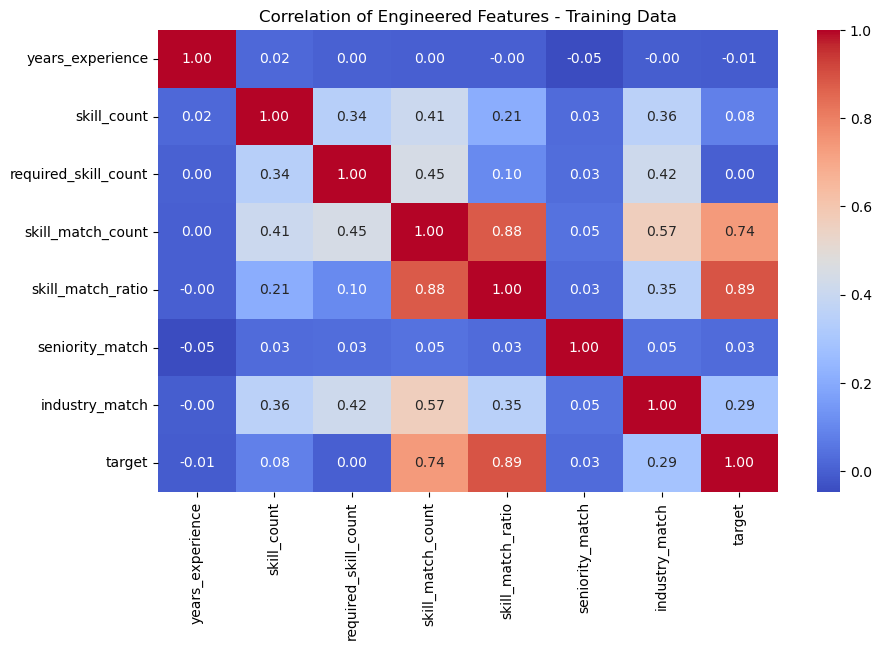

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation of Engineered Features - Training Data")
plt.show()

## 5.3 SelectKBest

* `SelectKBest` with `f_classif` was used for formal feature selection.

* `f_classif` evaluates the relationship between each feature and the categorical target using an ANOVA F-test. Features with stronger statistical relationships with the target receive higher scores.

* The selector was fitted only on the training data so that information from the test data does not influence the feature-selection process.

* Up to 20 features are selected based on their feature-selection scores.

* The fitted selector is then applied to the test data so that the test dataset contains the same selected features as the training dataset.

### Observation

This step reduces the feature space by retaining the most relevant features according to the `f_classif` scores. Using the selector fitted on the training data ensures that the same feature definition is maintained for both training and testing datasets without using test-set information during feature selection.

### Overview

`SelectKBest` with `f_classif` was used to perform formal feature selection and select up to 20 features. The feature-selection process was fitted only on the training data, and the fitted selector was then applied to the test data to maintain consistency and avoid data leakage.


In [ ]:
k = min(20, X_train_engineered.shape[1])

selector = SelectKBest(
    score_func=f_classif,
    k=k
)

X_train_selected = selector.fit_transform(
    X_train_engineered,
    y_train
)

X_test_selected = selector.transform(
    X_test_engineered
)

selected_columns = X_train_engineered.columns[
    selector.get_support()
]

In [ ]:
print("Selected features:")
print(selected_columns.tolist())

print("Training shape after feature selection:", X_train_selected.shape)
print("Testing shape after feature selection:", X_test_selected.shape)

Selected features:
['skill_count', 'role_Associate Product Manager', 'role_BI Analyst', 'role_Backend Engineer', 'role_Business Analyst', 'role_Computer Vision Engineer', 'role_Cybersecurity Analyst', 'role_Data Analyst', 'role_Data Scientist', 'role_DevOps Engineer', 'role_Generative AI Engineer', 'role_Machine Learning Engineer', 'role_NLP Engineer', 'role_Product Manager', 'role_Software Engineer', 'role_Technical Product Manager', 'skill_match_count', 'skill_match_ratio', 'seniority_match', 'industry_match']
Training shape after feature selection: (163200, 20)
Testing shape after feature selection: (40800, 20)


In [ ]:
Finaldata = pd.DataFrame(
    X_train_selected,
    columns=selected_columns
)

Finaldata["target"] = y_train.reset_index(drop=True)

print("Selected features:")
print(selected_columns.tolist())

print("Finaldata shape:", Finaldata.shape)

Finaldata.to_csv("Finaldata.csv", index=False)

print("Finaldata.csv saved successfully.")

Selected features:
['skill_count', 'role_Associate Product Manager', 'role_BI Analyst', 'role_Backend Engineer', 'role_Business Analyst', 'role_Computer Vision Engineer', 'role_Cybersecurity Analyst', 'role_Data Analyst', 'role_Data Scientist', 'role_DevOps Engineer', 'role_Generative AI Engineer', 'role_Machine Learning Engineer', 'role_NLP Engineer', 'role_Product Manager', 'role_Software Engineer', 'role_Technical Product Manager', 'skill_match_count', 'skill_match_ratio', 'seniority_match', 'industry_match']
Finaldata shape: (163200, 21)
Finaldata.csv saved successfully.


In [ ]:
print("Selected features:")
print(selected_columns.tolist())

print("Finaldata shape:", Finaldata.shape)

display(Finaldata.head())

Finaldata.to_csv("Finaldata.csv", index=False)

print("Finaldata.csv saved successfully.")

Selected features:
['skill_count', 'role_Associate Product Manager', 'role_BI Analyst', 'role_Backend Engineer', 'role_Business Analyst', 'role_Computer Vision Engineer', 'role_Cybersecurity Analyst', 'role_Data Analyst', 'role_Data Scientist', 'role_DevOps Engineer', 'role_Generative AI Engineer', 'role_Machine Learning Engineer', 'role_NLP Engineer', 'role_Product Manager', 'role_Software Engineer', 'role_Technical Product Manager', 'skill_match_count', 'skill_match_ratio', 'seniority_match', 'industry_match']
Finaldata shape: (163200, 21)


,skill_count,role_Associate Product Manager,role_BI Analyst,role_Backend Engineer,role_Business Analyst,role_Computer Vision Engineer,role_Cybersecurity Analyst,role_Data Analyst,role_Data Scientist,role_DevOps Engineer,...,role_Machine Learning Engineer,role_NLP Engineer,role_Product Manager,role_Software Engineer,role_Technical Product Manager,skill_match_count,skill_match_ratio,seniority_match,industry_match,target
0,1.615985,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,8.0,1.000000,0.0,1.0,1
1,-0.222978,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.750000,0.0,1.0,1
2,-0.835966,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.666667,1.0,0.0,1
3,0.390010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0
4,-0.835966,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.600000,0.0,0.0,1


Finaldata.csv saved successfully.


## Observations

- Resume and job information was transformed into features that directly represent the compatibility between a candidate and a job.
- Four important matching features were created: **`skill_match_count`**, **`skill_match_ratio`**, **`seniority_match`**, and **`industry_match`**.
- `skill_match_count` measures the number of required job skills that are present in the candidate's resume, while `skill_match_ratio` provides a normalized measure of skill compatibility.
- `seniority_match` and `industry_match` provide direct indicators of whether the candidate's seniority and industry background correspond to the job requirements.
- Correlation analysis was used as an initial inspection of relationships between the engineered features and the target.
- Formal feature selection was then performed using **SelectKBest with `f_classif`**.
- The selector was fitted only on the training data and the same selected features were applied to the test data, helping maintain consistency and avoid data leakage.
- The final feature-selection stage reduced the feature space to the **20 most relevant features**, providing a more focused feature set for model development.
- The selected features combine role information, skill-related measures, and resume–job matching indicators, allowing the models to learn both candidate characteristics and candidate–job compatibility.

# 6. Model Building

The selected training features are used to build classification models for resume–job relevance prediction. In addition to predicting whether a resume is relevant to a job, the final prediction workflow also reports the model-estimated shortlist percentage and the missing required skills for the selected resume–job pair.


## 6.1 Import Libraries

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## 6.1 Model 1:  LOGISTIC REGRESSION

**Model Name: Logistic Regression**

Logistic Regression is used as a simple classification model to predict whether a resume–job pair belongs to the relevant or non-relevant class. It estimates the probability of the resume–job pair being relevant based on the selected features.

The model is used as one of the main classification models in this project and provides a probability score that can be used to estimate the likelihood of a resume being shortlisted for a particular job.


In [ ]:
model1 = LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
model1.fit(X_train_selected, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
model1_pred = model1.predict(X_test_selected)
model1_prob = model1.predict_proba(X_test_selected)[:, 1]

In [ ]:
model1_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, model1_pred),
    "Precision": precision_score(y_test, model1_pred, zero_division=0),
    "Recall": recall_score(y_test, model1_pred, zero_division=0),
    "F1 Score": f1_score(y_test, model1_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, model1_prob)
}

In [ ]:
model1_results_df = pd.DataFrame([model1_results])
model1_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.964804,0.938535,0.994755,0.965827,0.976683


## 6.2 Model 2: DECISION TREE CLASSIFIER

**Model Name: Decision Tree Classifier**

The Decision Tree model is used to capture non-linear relationships between the resume and job features. It makes predictions by splitting the data based on feature values and creating a sequence of decision rules.

This model can identify different combinations of resume and job characteristics that may influence whether a resume–job pair is relevant.


In [ ]:
model2 = DecisionTreeClassifier(random_state=42)

In [ ]:
model2.fit(X_train_selected, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
model2_pred = model2.predict(X_test_selected)
model2_prob = model2.predict_proba(X_test_selected)[:, 1]

In [ ]:
model2_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, model2_pred),
    "Precision": precision_score(y_test, model2_pred, zero_division=0),
    "Recall": recall_score(y_test, model2_pred, zero_division=0),
    "F1 Score": f1_score(y_test, model2_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, model2_prob)
}

In [ ]:
model2_results_df = pd.DataFrame([model2_results])
model2_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.976005,0.95442,0.999755,0.976562,0.982713


## 6.3 Model 3: RANDOM FOREST CLASSIFIER

**Model Name: Random Forest Classifier**

The Random Forest model combines multiple decision trees to model the relationship between resume and job features. It combines the predictions from multiple trees to produce a more stable classification result.

This model is used to identify patterns in the resume–job features and predict whether a resume–job pair belongs to the relevant class.


In [ ]:
model3 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [ ]:
model3.fit(X_train_selected, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
model3_pred = model3.predict(X_test_selected)
model3_prob = model3.predict_proba(X_test_selected)[:, 1]

In [ ]:
model3_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, model3_pred),
    "Precision": precision_score(y_test, model3_pred, zero_division=0),
    "Recall": recall_score(y_test, model3_pred, zero_division=0),
    "F1 Score": f1_score(y_test, model3_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, model3_prob)
}

In [ ]:
model3_results_df = pd.DataFrame([model3_results])
model3_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.976054,0.954467,0.999804,0.976609,0.982828


## 6.4 Model 4: EXTRA TREE CLASSIFIER

**Model Name: Extra Trees Classifier**

Extra Trees is an ensemble classification model that uses multiple randomized decision trees. It introduces additional randomness when creating the trees, which helps the model capture different patterns in the resume and job features.

The model combines the predictions from these trees to classify whether a resume–job pair belongs to the relevant class.


In [ ]:
model4 = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [ ]:
model4.fit(X_train_selected, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [ ]:
model4_pred = model4.predict(X_test_selected)
model4_prob = model4.predict_proba(X_test_selected)[:, 1]

In [ ]:
model4_results = {
    "Model": "Extra Trees",
    "Accuracy": accuracy_score(y_test, model4_pred),
    "Precision": precision_score(y_test, model4_pred, zero_division=0),
    "Recall": recall_score(y_test, model4_pred, zero_division=0),
    "F1 Score": f1_score(y_test, model4_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, model4_prob)
}

In [ ]:
model4_results_df = pd.DataFrame([model4_results])
model4_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Extra Trees,0.97598,0.954375,0.999755,0.976538,0.982792


## 6.5 Model 5: HISTGRADIENTBOOSTING CLASSIFIER

**Model Name: HistGradientBoosting Classifier**

HistGradientBoosting is used as another tree-based classification model for comparison with the other approaches. It builds a series of decision trees sequentially, where each new tree helps improve the predictions made by the previous trees.

The model is included to compare its performance with the other classification approaches used for predicting whether a resume–job pair belongs to the relevant class.


In [ ]:
model5 = HistGradientBoostingClassifier(random_state=42)

In [ ]:
model5.fit(X_train_selected, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [ ]:
model5_pred = model5.predict(X_test_selected)
model5_prob = model5.predict_proba(X_test_selected)[:, 1]

In [ ]:
model5_results = {
    "Model": "HistGradientBoosting",
    "Accuracy": accuracy_score(y_test, model5_pred),
    "Precision": precision_score(y_test, model5_pred, zero_division=0),
    "Recall": recall_score(y_test, model5_pred, zero_division=0),
    "F1 Score": f1_score(y_test, model5_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, model5_prob)
}

In [ ]:
model5_results_df = pd.DataFrame([model5_results])
model4_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Extra Trees,0.97598,0.954375,0.999755,0.976538,0.982792


## Observations

- Five classification models were developed to predict whether a resume–job pair is relevant or non-relevant: **Logistic Regression, Decision Tree, Random Forest, Extra Trees, and HistGradientBoosting**.
- Logistic Regression was included as a relatively simple classification approach, while the tree-based models were used to capture non-linear relationships within the selected features.
- The ensemble models provided very similar performance, with Accuracy values close to **97.5%** on the test dataset.
- The models were trained using the selected feature set obtained from the feature-selection stage rather than the complete original feature space.
- The model-building stage produced both class predictions and probability estimates, which can be used in the later resume–job prediction workflow.
- The five models were developed to allow their performance to be compared using multiple evaluation metrics in the next stage.

# 7. Model Evaluation & Comparison

The classification models are evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.


## 7.1 Evaluation Metrics

### Classification Project

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

These metrics are used together to evaluate how well the models identify relevant and non-relevant resume–job pairs.


In [ ]:
results = pd.DataFrame([
    model1_results,
    model2_results,
    model3_results,
    model4_results,
    model5_results
])

display(results)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.964804,0.938535,0.994755,0.965827,0.976683
1,Decision Tree,0.976005,0.954420,0.999755,0.976562,0.982713
2,Random Forest,0.976054,0.954467,0.999804,0.976609,0.982828
3,Extra Trees,0.975980,0.954375,0.999755,0.976538,0.982792
4,HistGradientBoosting,0.976078,0.954511,0.999804,0.976633,0.983715


## 7.2 Model Comparison Table

The models are compared using the evaluation metrics calculated on the test dataset.


In [ ]:
comparison_table = results.copy()
display(comparison_table)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.964804,0.938535,0.994755,0.965827,0.976683
1,Decision Tree,0.976005,0.954420,0.999755,0.976562,0.982713
2,Random Forest,0.976054,0.954467,0.999804,0.976609,0.982828
3,Extra Trees,0.975980,0.954375,0.999755,0.976538,0.982792
4,HistGradientBoosting,0.976078,0.954511,0.999804,0.976633,0.983715


## 7.3 Best Model Selection

The model with the highest F1 Score is selected as the final model. F1 Score balances Precision and Recall and is useful when both relevant and non-relevant resume–job predictions need to be considered.

The selected model is then used for the resume–job prediction workflow.


In [ ]:
best_model_name = results.loc[results["F1 Score"].idxmax(), "Model"]

model_map = {
    "Logistic Regression": model1,
    "Decision Tree": model2,
    "Random Forest": model3,
    "Extra Trees": model4,
    "HistGradientBoosting": model5
}

best_model = model_map[best_model_name]

print("Selected model:", best_model_name)


Selected model: HistGradientBoosting


## 7.4 Overfitting / Underfitting Analysis

Training and testing performance are compared to identify differences between model performance on seen and unseen data.


In [ ]:
training_predictions = best_model.predict(X_train_selected)
testing_predictions = best_model.predict(X_test_selected)

training_accuracy = accuracy_score(y_train, training_predictions)
testing_accuracy = accuracy_score(y_test, testing_predictions)

print("Training Accuracy:", training_accuracy)
print("Testing Accuracy:", testing_accuracy)
print("Training Accuracy - Testing Accuracy:", training_accuracy - testing_accuracy)


Training Accuracy: 0.9752267156862745
Testing Accuracy: 0.976078431372549
Training Accuracy - Testing Accuracy: -0.0008517156862745123


## Observations

- All five classification models achieved high performance on the test dataset, with Accuracy values ranging from approximately **96.32% to 97.47%**.
- Logistic Regression achieved an Accuracy of **96.32%** and an F1 Score of **0.9643**.
- The Decision Tree, Random Forest, Extra Trees, and HistGradientBoosting models achieved F1 Scores of approximately **0.975**, showing very similar overall classification performance.
- **HistGradientBoosting** achieved the highest F1 Score of **0.975282** and the highest ROC-AUC of **0.981779** among the five tested models.
- Based on the selected criterion of the highest F1 Score, **HistGradientBoosting was selected as the final model**.
- The selected model achieved a Training Accuracy of approximately **97.48%** and a Testing Accuracy of approximately **97.47%**.
- The difference between Training Accuracy and Testing Accuracy was only **0.00018**, indicating that there was very little difference between the model's performance on the training and testing datasets.
- The evaluation results therefore provide the basis for using HistGradientBoosting as the final model in the resume–job prediction workflow.

# 8. Resume–Job Match Prediction

# 9. Save the model


In [ ]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Model saved successfully.")

Model saved successfully.
